In [1]:
!pip install roboflow
!pip install ultralytics
from roboflow import Roboflow
import shutil

rf = Roboflow(api_key="5UlKGUPrvZVUYVgu31Jm")
project = rf.workspace("tudorcworkspaceroboflow").project("yolov8-taco")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.6 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to YOLOv8-taco-3 in yolov8:: 100%|██████████| 3010/3010 [00:00<00:00, 4604.41it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
import glob

label_files = glob.glob("YOLOv8-taco-3/**/labels/*.txt", recursive=True)

for f in label_files[:3]:
    with open(f) as file:
        lines = file.readlines()
    print(f"{f}:")
    print(f"  {lines[0].strip()}")
    print(f"  parts count: {len(lines[0].strip().split())}")

YOLOv8-taco-3/train/labels/000069_JPG.rf.26447b472c332391fd788e772f74300e.txt:
  25 0.39368872499999996 0.6180555562500001 0.3982843140625 0.6008986921874999 0.39767156875 0.5927287578125 0.3900122546875 0.580882353125 0.3829656859375 0.5776143796875 0.376225490625 0.5751633984375 0.3700980390625 0.5751633984375 0.3612132359375 0.5739379078125 0.35600490156250003 0.573120915625 0.3517156859375 0.5743464046875 0.34681372499999996 0.5739379078125 0.344056371875 0.5776143796875 0.3391544125 0.5767973859375 0.33700980468749997 0.580882353125 0.33149509843749997 0.5829248359375 0.3296568625 0.5874183000000001 0.3259803921875 0.5955882359375 0.32444852968750004 0.6008986921874999 0.328125 0.6172385625000001 0.335477940625 0.6286764703125 0.343443628125 0.6327614374999999 0.3501838234375 0.634803921875 0.3544730390625 0.63521241875 0.3645833328125 0.63521241875 0.375306371875 0.6323529406249999 0.38511029375 0.6274509796875 0.39368872499999996 0.6180555562500001
  parts count: 55
YOLOv8-taco-

In [3]:
import random, os

label_dir = "YOLOv8-taco-3/train/labels"
file = random.choice(os.listdir(label_dir))

print(file)
print(open(os.path.join(label_dir, file)).read())

000087_jpg.rf.20e5c751fe59791fb41678a0149a1d5b.txt
33 0.584325396875 0.48511904687499996 0.5770502640624999 0.4764384921875 0.563161375 0.46949404687499996 0.5419973546875 0.4677579359375 0.5267857140625 0.47073412656249997 0.5109126984375 0.4794146828125 0.5042989421875 0.487351190625 0.5023148140625 0.502728175 0.509259259375 0.5106646828125 0.49570105781249996 0.5171130953125 0.5042989421875 0.534226190625 0.49404761875 0.533730159375 0.4765211640625 0.5414186515625 0.4675925921875 0.5481150796875001 0.4507275125 0.552579365625 0.424603175 0.5644841265625 0.41732804218749997 0.5689484125 0.42526454999999996 0.5793650796875001 0.4639550265625 0.5917658734375 0.4738756609375 0.5959821421875 0.47850529062499997 0.599950396875 0.49603174531249994 0.609375 0.5049603171875 0.6106150796875001 0.5271164015625 0.6113591265625 0.5492724875 0.60987103125 0.5492724875 0.60615079375 0.55687830625 0.6076388890625 0.5667989421875 0.6029265875 0.5611772484374999 0.587549603125 0.5677910046875 0.564

In [4]:
import yaml

with open("YOLOv8-taco-3/data.yaml", 'r') as f:
    data = yaml.safe_load(f)

names = data.get('names', [])
if isinstance(names, dict):
    names = [names[i] for i in range(len(names))]

print(f"Total classes: {len(names)}")
print("\nID → Class Name:")
for i, name in enumerate(names):
    print(f"  {i:2d} : {name}")

Total classes: 59

ID → Class Name:
   0 : Aerosol
   1 : Aluminium blister pack
   2 : Aluminium foil
   3 : Battery
   4 : Broken glass
   5 : Carded blister pack
   6 : Cigarette
   7 : Clear plastic bottle
   8 : Corrugated carton
   9 : Crisp packet
  10 : Disposable food container
  11 : Disposable plastic cup
  12 : Drink can
  13 : Drink carton
  14 : Egg carton
  15 : Foam cup
  16 : Foam food container
  17 : Food Can
  18 : Food waste
  19 : Garbage bag
  20 : Glass bottle
  21 : Glass cup
  22 : Glass jar
  23 : Magazine paper
  24 : Meal carton
  25 : Metal bottle cap
  26 : Metal lid
  27 : Normal paper
  28 : Other carton
  29 : Other plastic
  30 : Other plastic bottle
  31 : Other plastic container
  32 : Other plastic cup
  33 : Other plastic wrapper
  34 : Paper bag
  35 : Paper cup
  36 : Paper straw
  37 : Pizza box
  38 : Plastic bottle cap
  39 : Plastic film
  40 : Plastic glooves
  41 : Plastic lid
  42 : Plastic straw
  43 : Plastic utensils
  44 : Polypropyle

In [5]:
DATASET_PATH = "YOLOv8-taco-3"

MAPPING = {
    # --- PLASTIC (0) ---
    7:  0, 10: 0, 11: 0, 15: 0, 16: 0, 19: 0,
    29: 0, 30: 0, 31: 0, 32: 0, 33: 0, 38: 0,
    39: 0, 40: 0, 41: 0, 42: 0, 43: 0, 44: 0,
    49: 0, 50: 0, 51: 0, 53: 0, 56: 0,

    # --- METAL (1) ---
    0:  1,  1: 1,  2: 1, 12: 1, 17: 1,
    25: 1, 26: 1, 45: 1, 47: 1,

    # --- PAPER (2) ---
    8:  2, 13: 2, 14: 2, 23: 2, 24: 2,
    27: 2, 28: 2, 34: 2, 35: 2, 36: 2,
    37: 2, 55: 2, 58: 2,

    # --- GLASS (3) ---
    4:  3, 20: 3, 21: 3, 22: 3,

    # --- TRASH (4) ---
    3:  4,  5: 4,  6: 4,  9: 4, 18: 4,
    46: 4, 48: 4, 52: 4, 54: 4, 57: 4,
}

label_files = glob.glob(f"{DATASET_PATH}/**/labels/*.txt", recursive=True)
print(f"Found {len(label_files)} label files...")

class_counts = {0:0, 1:0, 2:0, 3:0, 4:0}
converted = 0
skipped   = 0

for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()

        # Need at least class_id + one x,y pair
        if len(parts) < 3:
            skipped += 1
            continue

        old_id = int(parts[0])
        new_id = MAPPING.get(old_id, 4)  # default to Trash if unmapped

        # Handle BOTH formats:
        # Segmentation: class x1 y1 x2 y2 x3 y3 ... (many points)
        # Bounding box: class cx cy w h              (5 values)
        coords = list(map(float, parts[1:]))

        if len(coords) == 4:
            # Already bounding box format
            cx, cy, w, h = coords
        else:
            # Segmentation — convert polygon to bounding box
            xs = coords[0::2]
            ys = coords[1::2]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            cx = (x_min + x_max) / 2
            cy = (y_min + y_max) / 2
            w  =  x_max - x_min
            h  =  y_max - y_min

        new_lines.append(f"{new_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        class_counts[new_id] += 1
        converted += 1

    with open(file_path, 'w') as f:
        f.writelines(new_lines)

# Results
print(f"\n✅ Converted {converted} annotations")
print(f"   Skipped   {skipped} malformed lines")
print(f"\nClass counts after remap:")
names = ['Plastic', 'Metal', 'Paper', 'Glass', 'Trash']
for cls_id, name in enumerate(names):
    print(f"  {name:10} (class {cls_id}): {class_counts[cls_id]} instances")

Found 1499 label files...

✅ Converted 4823 annotations
   Skipped   0 malformed lines

Class counts after remap:
  Plastic    (class 0): 2227 instances
  Metal      (class 1): 563 instances
  Paper      (class 2): 456 instances
  Glass      (class 3): 255 instances
  Trash      (class 4): 1322 instances


In [6]:
counts = {i: 0 for i in range(5)}
names  = ['Plastic', 'Metal', 'Paper', 'Glass', 'Trash']

for f in glob.glob("YOLOv8-taco-3/**/labels/*.txt", recursive=True):
    with open(f) as file:
        for line in file:
            parts = line.strip().split()
            if parts:
                counts[int(parts[0])] += 1

all_good = True
print("Class verification:")
for i, name in enumerate(names):
    status = "✅" if counts[i] > 0 else "❌ STOP"
    print(f"  {status} {name:10}: {counts[i]} instances")
    if counts[i] == 0:
        all_good = False

if all_good:
    print("\n✅ SAFE — proceed to oversample")
else:
    print("\n❌ STOP — fix remap before continuing")
    raise RuntimeError("Labels not properly remapped — do not continue")

Class verification:
  ✅ Plastic   : 2227 instances
  ✅ Metal     : 563 instances
  ✅ Paper     : 456 instances
  ✅ Glass     : 255 instances
  ✅ Trash     : 1322 instances

✅ SAFE — proceed to oversample


In [8]:
import os, glob, shutil, random, yaml

# ── Config ─────────────────────────────────────────────────────
DATASET_PATH     = "YOLOv8-taco-3"
NEW_DATASET_PATH = "YOLOv8-taco-split"

TARGETS = {
    1: 1500,   # Metal
    2: 1500,   # Paper
    3: 1500,   # Glass
}

image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
names      = ['Plastic', 'Metal', 'Paper', 'Glass', 'Trash']

train_img_dir = os.path.join(DATASET_PATH, "train", "images")
train_lbl_dir = os.path.join(DATASET_PATH, "train", "labels")
val_img_dir   = os.path.join(DATASET_PATH, "valid", "images")
val_lbl_dir   = os.path.join(DATASET_PATH, "valid", "labels")
test_img_dir  = os.path.join(DATASET_PATH, "test",  "images")
test_lbl_dir  = os.path.join(DATASET_PATH, "test",  "labels")

# ── STEP 1: Wipe old split ─────────────────────────────────────
if os.path.exists(NEW_DATASET_PATH):
    shutil.rmtree(NEW_DATASET_PATH)
    print("🗑️  Removed old YOLOv8-taco-split")

# ── STEP 2: Remove leftover _os files from previous runs ──────
removed = 0
for f in glob.glob(os.path.join(train_img_dir, "*_os*")):
    os.remove(f)
    removed += 1
for f in glob.glob(os.path.join(train_lbl_dir, "*_os*")):
    os.remove(f)
    removed += 1
if removed:
    print(f"🗑️  Removed {removed} leftover oversampled files")

# ── STEP 3: Oversample on YOLOv8-taco-3/train ─────────────────
print("\n[1/2] Oversampling minority classes ...")

class_images = {0:[], 1:[], 2:[], 3:[], 4:[]}

for img_file in os.listdir(train_img_dir):
    if os.path.splitext(img_file)[1].lower() not in image_exts:
        continue
    stem     = os.path.splitext(img_file)[0]
    lbl_file = os.path.join(train_lbl_dir, stem + ".txt")
    if not os.path.exists(lbl_file):
        continue
    with open(lbl_file) as f:
        lines = [l.strip() for l in f if l.strip()]
    if not lines:
        continue
    for cls in set(int(l.split()[0]) for l in lines):
        if cls in class_images:
            class_images[cls].append(img_file)

current_counts = {i: 0 for i in range(5)}
for f in glob.glob(os.path.join(train_lbl_dir, "*.txt")):
    with open(f) as file:
        for line in file:
            parts = line.strip().split()
            if parts:
                current_counts[int(parts[0])] += 1

print("Before oversampling:")
for cls_id in range(5):
    print(f"  {names[cls_id]:10} — images: {len(class_images[cls_id]):4}  instances: {current_counts[cls_id]}")

print("\nOversampling...")
for cls_id, target in TARGETS.items():
    src_imgs = class_images[cls_id]
    current  = current_counts[cls_id]

    if not src_imgs:
        print(f"  ⚠️  No images for {names[cls_id]} — skipping")
        continue
    if current >= target:
        print(f"  ✅ {names[cls_id]} already at {current} — skipping")
        continue

    needed = target - current
    added  = 0
    while added < needed:
        src_img   = random.choice(src_imgs)
        stem, ext = os.path.splitext(src_img)
        new_stem  = f"{stem}_os{cls_id}_{added}"
        shutil.copy2(
            os.path.join(train_img_dir, src_img),
            os.path.join(train_img_dir, new_stem + ext),
        )
        shutil.copy2(
            os.path.join(train_lbl_dir, stem + ".txt"),
            os.path.join(train_lbl_dir, new_stem + ".txt"),
        )
        added += 1
    print(f"  ✅ {names[cls_id]:10} — added {added} duplicates  ({current} → {current + added})")

final_counts = {i: 0 for i in range(5)}
for f in glob.glob(os.path.join(train_lbl_dir, "*.txt")):
    with open(f) as file:
        for line in file:
            parts = line.strip().split()
            if parts:
                final_counts[int(parts[0])] += 1

print("\nAfter oversampling:")
for cls_id in range(5):
    status = "✅" if final_counts[cls_id] > 0 else "❌"
    print(f"  {status} {names[cls_id]:10} (class {cls_id}): {final_counts[cls_id]} instances")

if any(final_counts[i] == 0 for i in range(5)):
    raise RuntimeError("❌ Some classes still 0 — fix remap before continuing")

# ── STEP 4: Copy into split folders ───────────────────────────
# Train → ALL files from YOLOv8-taco-3/train (includes _os copies)
# Val   → ALL files from YOLOv8-taco-3/valid (untouched originals)
# Test  → ALL files from YOLOv8-taco-3/test  (untouched originals)
# Replace STEP 4 in your oversample_and_split.py with this:

print("\n[2/2] Pooling ALL images then splitting 70/15/15 ...")

# Pool ALL pairs from all 3 original splits
all_pairs = []
for src_img_dir, src_lbl_dir in [
    (train_img_dir, train_lbl_dir),
    (val_img_dir,   val_lbl_dir),
    (test_img_dir,  test_lbl_dir),
]:
    if not os.path.isdir(src_img_dir):
        continue
    for img_file in os.listdir(src_img_dir):
        if os.path.splitext(img_file)[1].lower() not in image_exts:
            continue
        stem     = os.path.splitext(img_file)[0]
        lbl_file = os.path.join(src_lbl_dir, stem + ".txt")
        if os.path.exists(lbl_file):
            all_pairs.append((
                os.path.join(src_img_dir, img_file),
                lbl_file,
                img_file,
                stem + ".txt"
            ))

print(f"Total pairs pooled (including oversampled): {len(all_pairs)}")

random.seed(42)
random.shuffle(all_pairs)

total   = len(all_pairs)
n_train = int(total * 0.70)
n_val   = int(total * 0.15)

train_pairs = all_pairs[:n_train]
val_pairs   = all_pairs[n_train:n_train + n_val]
test_pairs  = all_pairs[n_train + n_val:]

print(f"Split — Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(NEW_DATASET_PATH, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(NEW_DATASET_PATH, split, 'labels'), exist_ok=True)

def copy_pairs(pairs, split):
    dst_img = os.path.join(NEW_DATASET_PATH, split, 'images')
    dst_lbl = os.path.join(NEW_DATASET_PATH, split, 'labels')
    for img_src, lbl_src, img_name, lbl_name in pairs:
        shutil.copy2(img_src, os.path.join(dst_img, img_name))
        shutil.copy2(lbl_src, os.path.join(dst_lbl, lbl_name))

copy_pairs(train_pairs, 'train')
copy_pairs(val_pairs,   'valid')
copy_pairs(test_pairs,  'test')

n_train = len(train_pairs)
n_val   = len(val_pairs)
n_test  = len(test_pairs)

print(f"  Train : {n_train} images  ← includes oversampled copies")
print(f"  Val   : {n_val}   images")
print(f"  Test  : {n_test}  images")

# Write data.yaml
data = {
    'path'  : f'/content/{NEW_DATASET_PATH}',
    'train' : 'train/images',
    'val'   : 'valid/images',
    'test'  : 'test/images',
    'nc'    : 5,
    'names' : ['Plastic', 'Metal', 'Paper', 'Glass', 'Trash']
}
with open(os.path.join(NEW_DATASET_PATH, "data.yaml"), 'w') as f:
    yaml.dump(data, f, sort_keys=False)

# ── STEP 5: Final verification ─────────────────────────────────
print("\nFinal train class distribution in YOLOv8-taco-split/train:")
split_counts = {i: 0 for i in range(5)}
for f in glob.glob(os.path.join(NEW_DATASET_PATH, "train", "labels", "*.txt")):
    with open(f) as file:
        for line in file:
            parts = line.strip().split()
            if parts:
                split_counts[int(parts[0])] += 1

all_good = True
for cls_id in range(5):
    status = "✅" if split_counts[cls_id] > 0 else "❌"
    print(f"  {status} {names[cls_id]:10} (class {cls_id}): {split_counts[cls_id]} instances")
    if split_counts[cls_id] == 0:
        all_good = False

if all_good:
    print(f"\n✅ All done — safe to train!")
    print(f"   Train : {n_train} images  |  Val : {n_val}  |  Test : {n_test}")
    print(f"   YAML  : /content/{NEW_DATASET_PATH}/data.yaml")
else:
    print("\n❌ Some classes missing — do not train")

🗑️  Removed old YOLOv8-taco-split
🗑️  Removed 7340 leftover oversampled files

[1/2] Oversampling minority classes ...
Before oversampling:
  Plastic    — images:  760  instances: 1519
  Metal      — images:  206  instances: 386
  Paper      — images:  218  instances: 315
  Glass      — images:   62  instances: 129
  Trash      — images:  342  instances: 860

Oversampling...
  ✅ Metal      — added 1114 duplicates  (386 → 1500)
  ✅ Paper      — added 1185 duplicates  (315 → 1500)
  ✅ Glass      — added 1371 duplicates  (129 → 1500)

After oversampling:
  ✅ Plastic    (class 0): 6140 instances
  ✅ Metal      (class 1): 3909 instances
  ✅ Paper      (class 2): 2621 instances
  ✅ Glass      (class 3): 3367 instances
  ✅ Trash      (class 4): 5206 instances

[2/2] Pooling ALL images then splitting 70/15/15 ...
Total pairs pooled (including oversampled): 5169
Split — Train: 3618 | Val: 775 | Test: 776
  Train : 3618 images  ← includes oversampled copies
  Val   : 775   images
  Test  : 776  

In [9]:
counts = {i: 0 for i in range(5)}
names  = ['Plastic', 'Metal', 'Paper', 'Glass', 'Trash']

for f in glob.glob("YOLOv8-taco-split/train/labels/*.txt"):
    with open(f) as file:
        for line in file:
            parts = line.strip().split()
            if parts:
                counts[int(parts[0])] += 1

print("Train class distribution:")
all_good = True
for i, name in enumerate(names):
    status = "✅" if counts[i] > 0 else "❌ STOP"
    print(f"  {status} {name:10}: {counts[i]} instances")
    if counts[i] == 0:
        all_good = False

if all_good:
    print("\n✅ All classes present — safe to train")
else:
    print("\n❌ Missing classes — must re-download and redo from scratch")

Train class distribution:
  ✅ Plastic   : 4798 instances
  ✅ Metal     : 2747 instances
  ✅ Paper     : 1975 instances
  ✅ Glass     : 2439 instances
  ✅ Trash     : 4109 instances

✅ All classes present — safe to train


In [10]:
"""
YOLOv8 Training Script (Upgraded 59 Classes)
================================================
Upgraded to the YOLOv8n (nano) model for more brain power,
using AdamW and Cosine LR for faster, deeper learning.
"""

import os
from ultralytics import YOLO

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────
DATASET_PATH = "/content/YOLOv8-taco-split"
YAML_PATH    = os.path.join(DATASET_PATH, "data.yaml")

# UPGRADE 1: Swapped 'n' (Nano) for 's' (Small)
MODEL_SIZE   = "yolov8s.pt"
DEVICE       = 0

# ─────────────────────────────────────────────
# TRAIN
# ─────────────────────────────────────────────
def train():
    if not os.path.exists(YAML_PATH):
        print(f"❌ ERROR: Cannot find {YAML_PATH}. Did you unzip the dataset?")
        return

    print("\n🚀 Starting Upgraded 59-Class Training...\n")
    model = YOLO(MODEL_SIZE)

    results = model.train(
        data         = YAML_PATH,
        epochs       = 100,
        imgsz        = 640,
        batch        = 8,
        device       = DEVICE,
        project      = "yolov8_run",
        name         = "experiment_07_upgraded_brain",
        lr0          = 0.001,
        patience     = 50,

        # ─────────────────────────────────────────────
        # SYSTEM FIXES & OPTIMIZERS
        # ─────────────────────────────────────────────
        workers      = 0,         # Prevents Colab from crashing
        optimizer    = 'AdamW',   # UPGRADE 2: Faster learning on messy data
        cos_lr       = True,      # UPGRADE 3: Smoothly glides to the final accuracy

        # ─────────────────────────────────────────────
        # HEAVY AUGMENTATIONS
        # ─────────────────────────────────────────────
        mosaic       = 1.0,
        mixup        = 0.2,
        copy_paste   = 0.2,
        degrees      = 15.0,
        translate    = 0.1,
        scale        = 0.5,
        fliplr       = 0.5,
    )

if __name__ == "__main__":
    train()


🚀 Starting Upgraded 59-Class Training...

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/YOLOv8-taco-split/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=experiment_07_upgraded_brain, nbs=64, nms=False, opset

In [12]:
import os

run_path = "/content/runs/detect/yolov8_run/experiment_07_upgraded_brain"
print("Files saved by training:")
for f in sorted(os.listdir(run_path)):
    print(f"  {f}")

Files saved by training:
  BoxF1_curve.png
  BoxPR_curve.png
  BoxP_curve.png
  BoxR_curve.png
  args.yaml
  confusion_matrix.png
  confusion_matrix_normalized.png
  labels.jpg
  results.csv
  results.png
  train_batch0.jpg
  train_batch1.jpg
  train_batch2.jpg
  train_batch40770.jpg
  train_batch40771.jpg
  train_batch40772.jpg
  val_batch0_labels.jpg
  val_batch0_pred.jpg
  val_batch1_labels.jpg
  val_batch1_pred.jpg
  val_batch2_labels.jpg
  val_batch2_pred.jpg
  weights



  F1 Curve


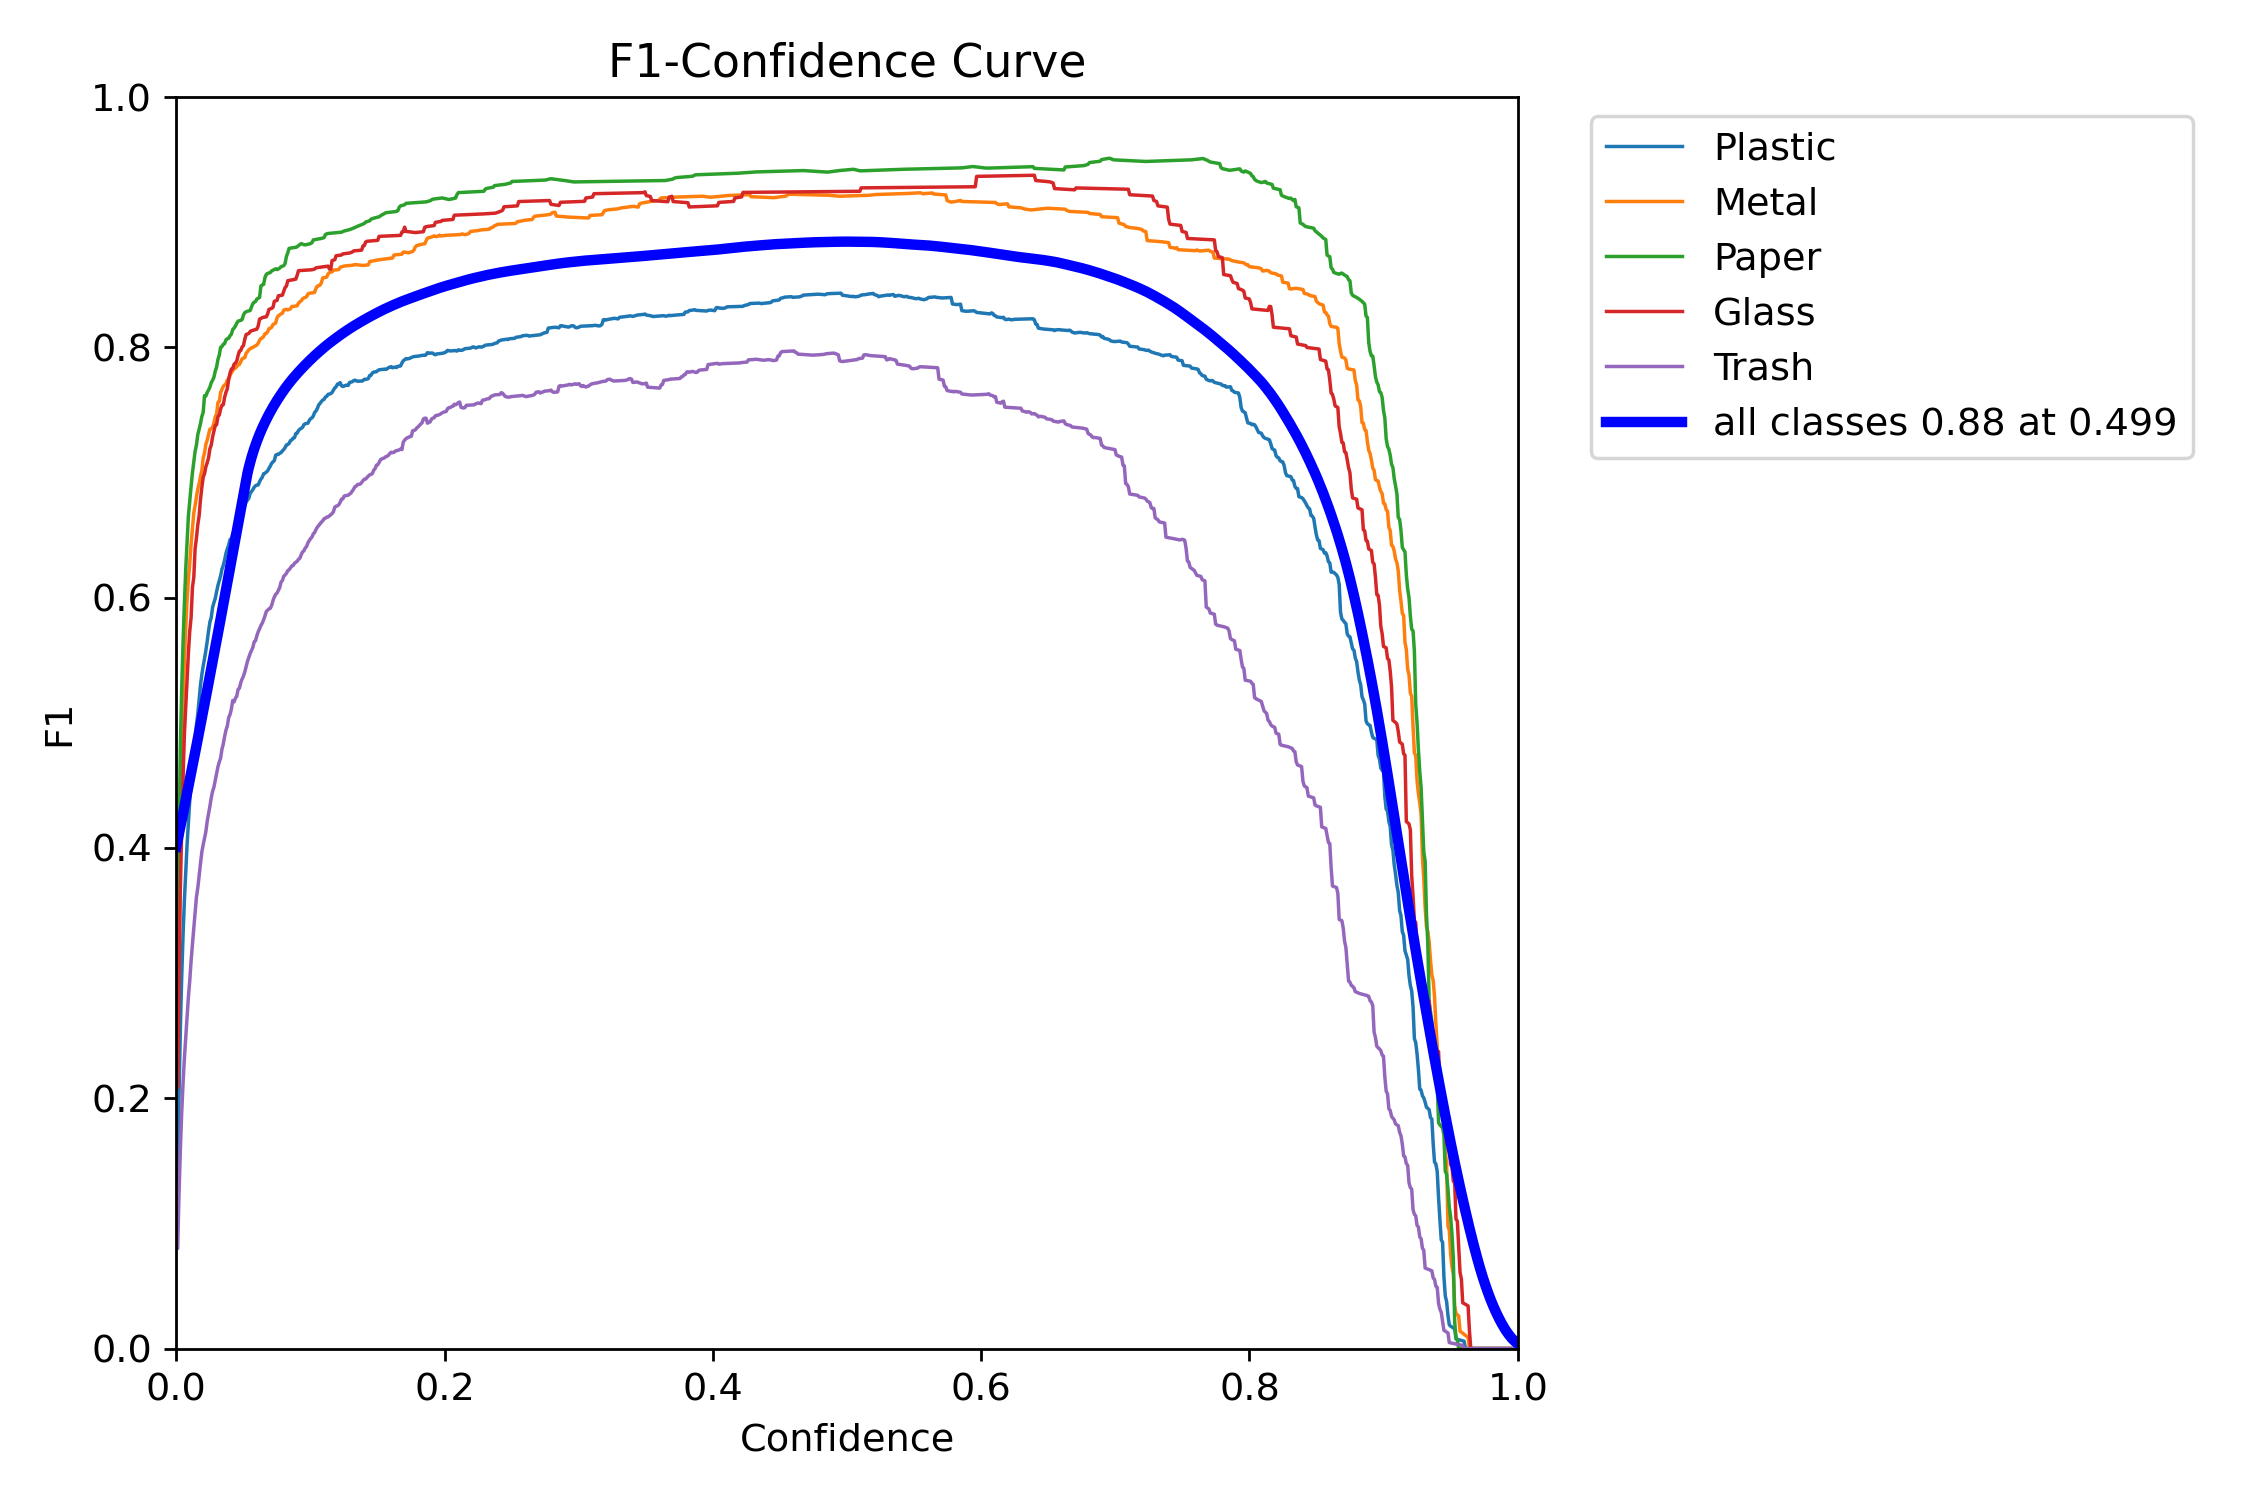


  Confusion Matrix


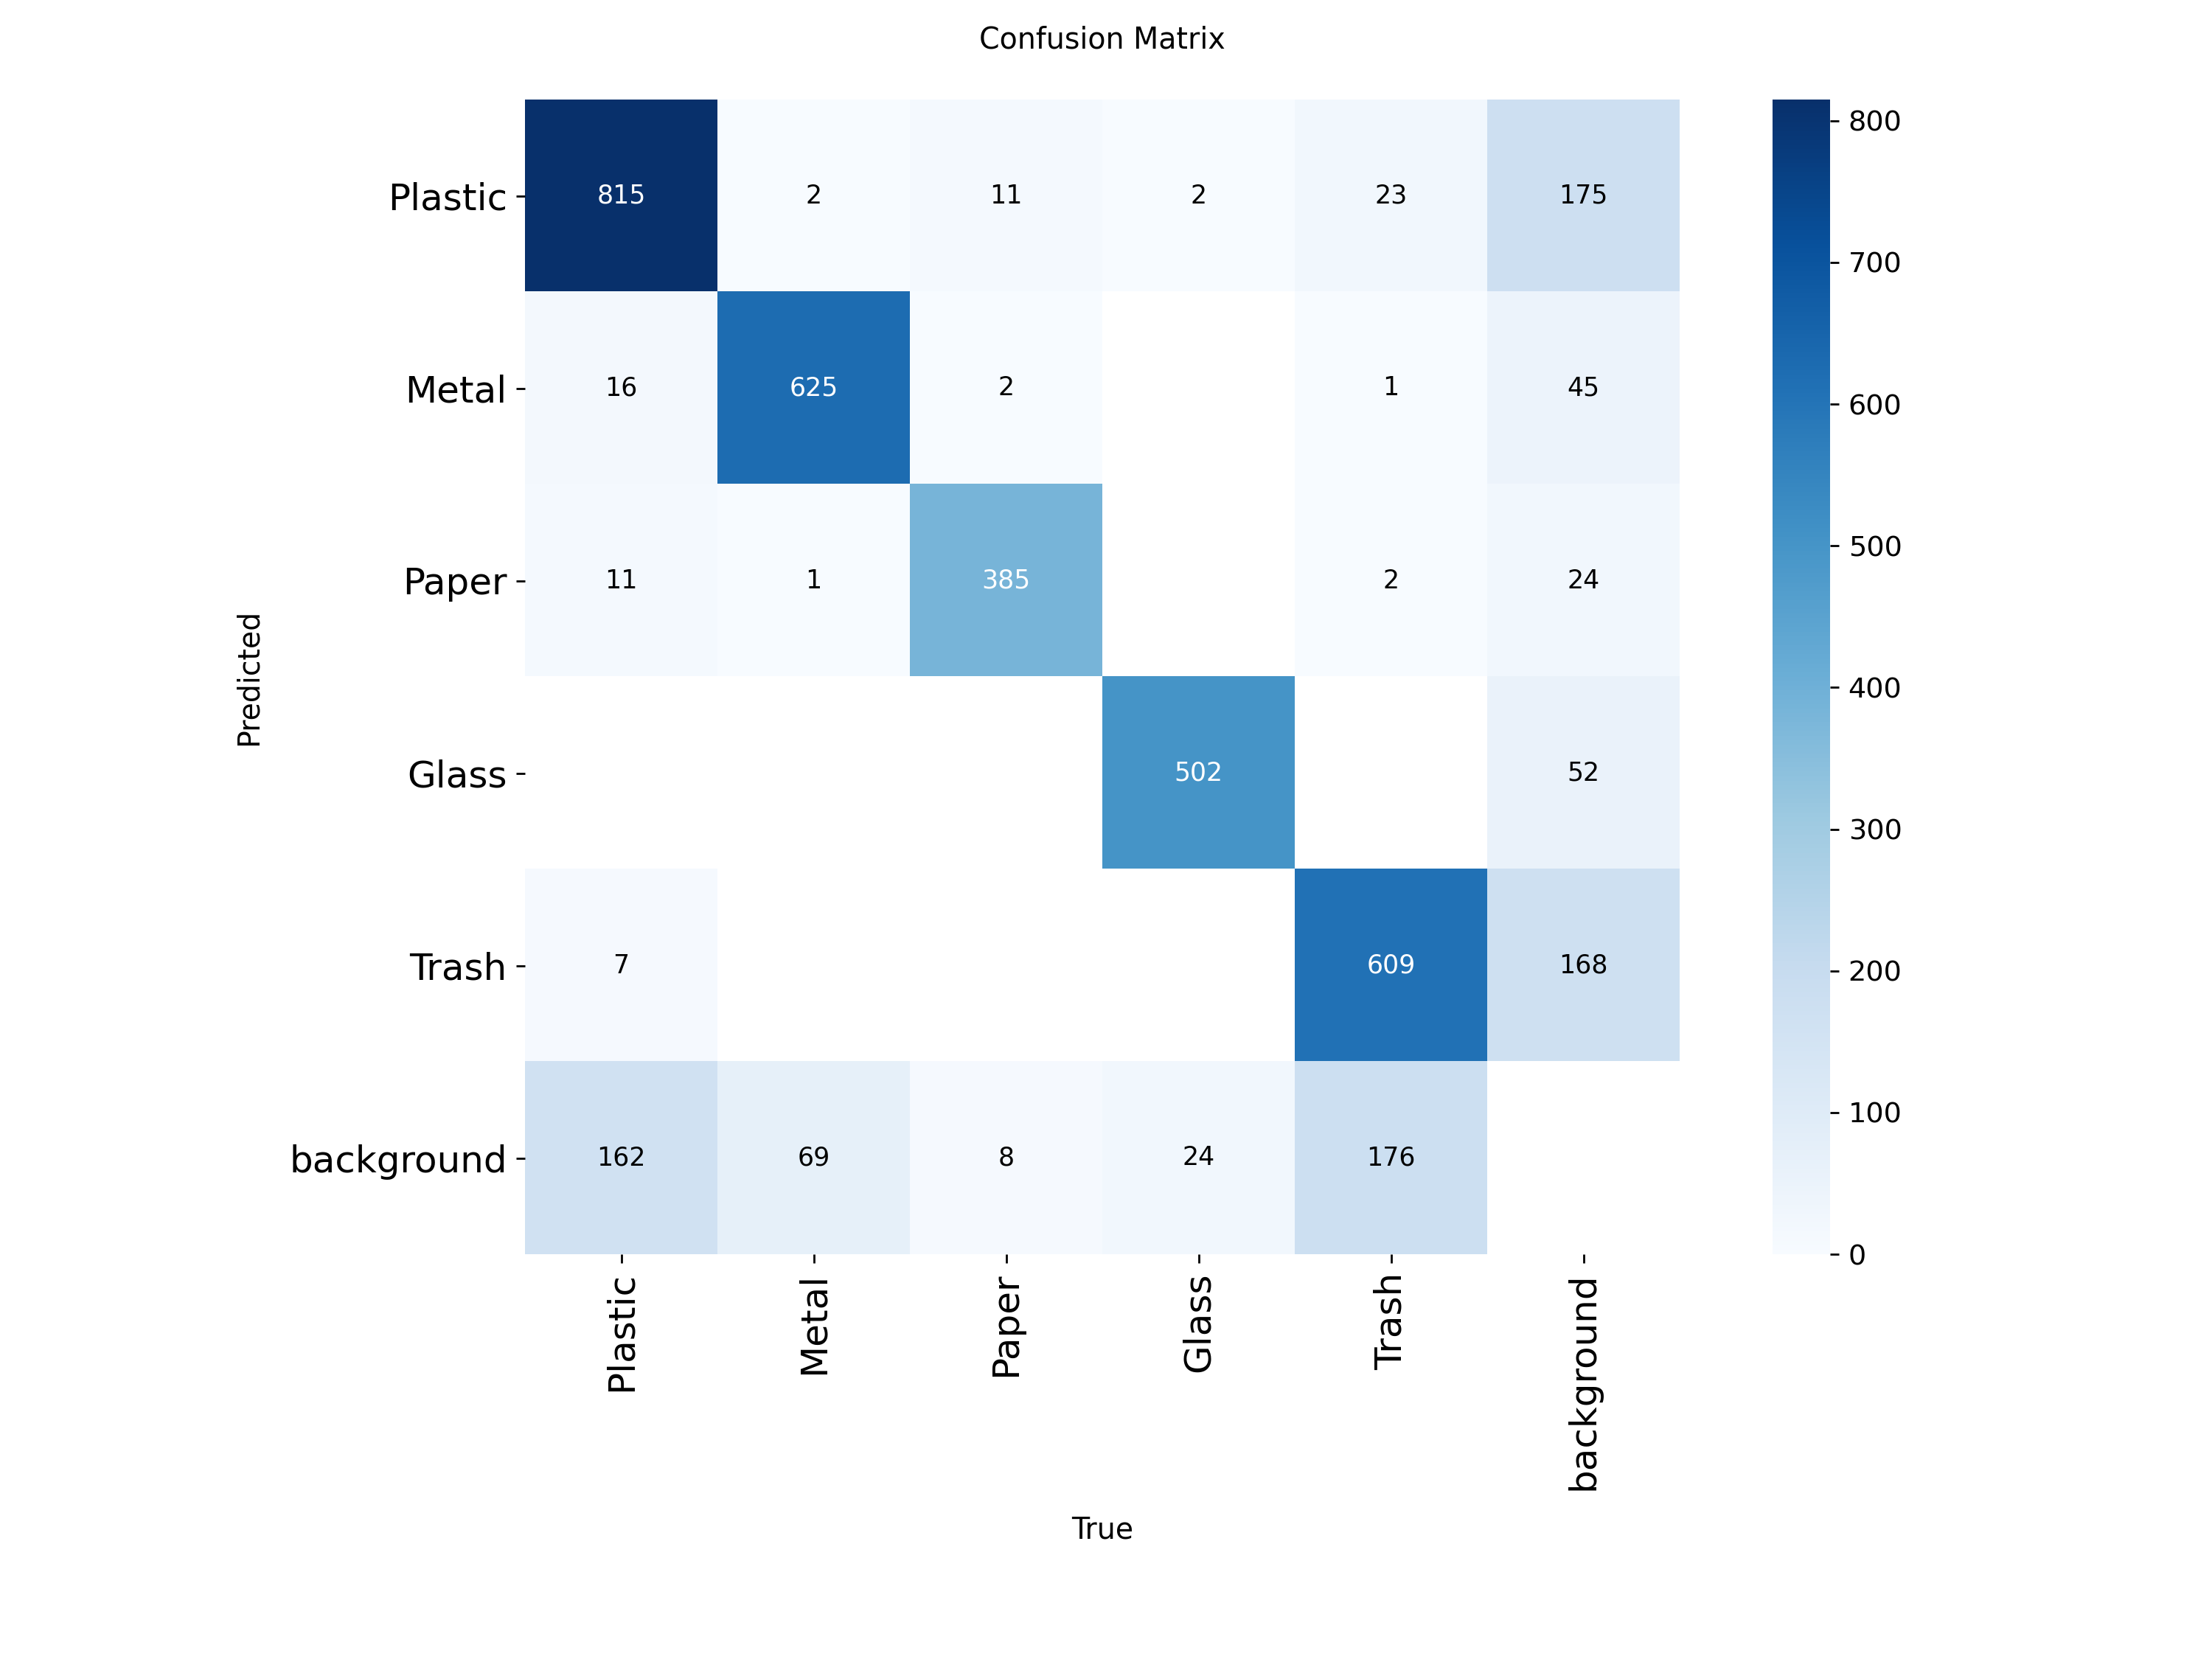


  Confusion Matrix (Normalized)


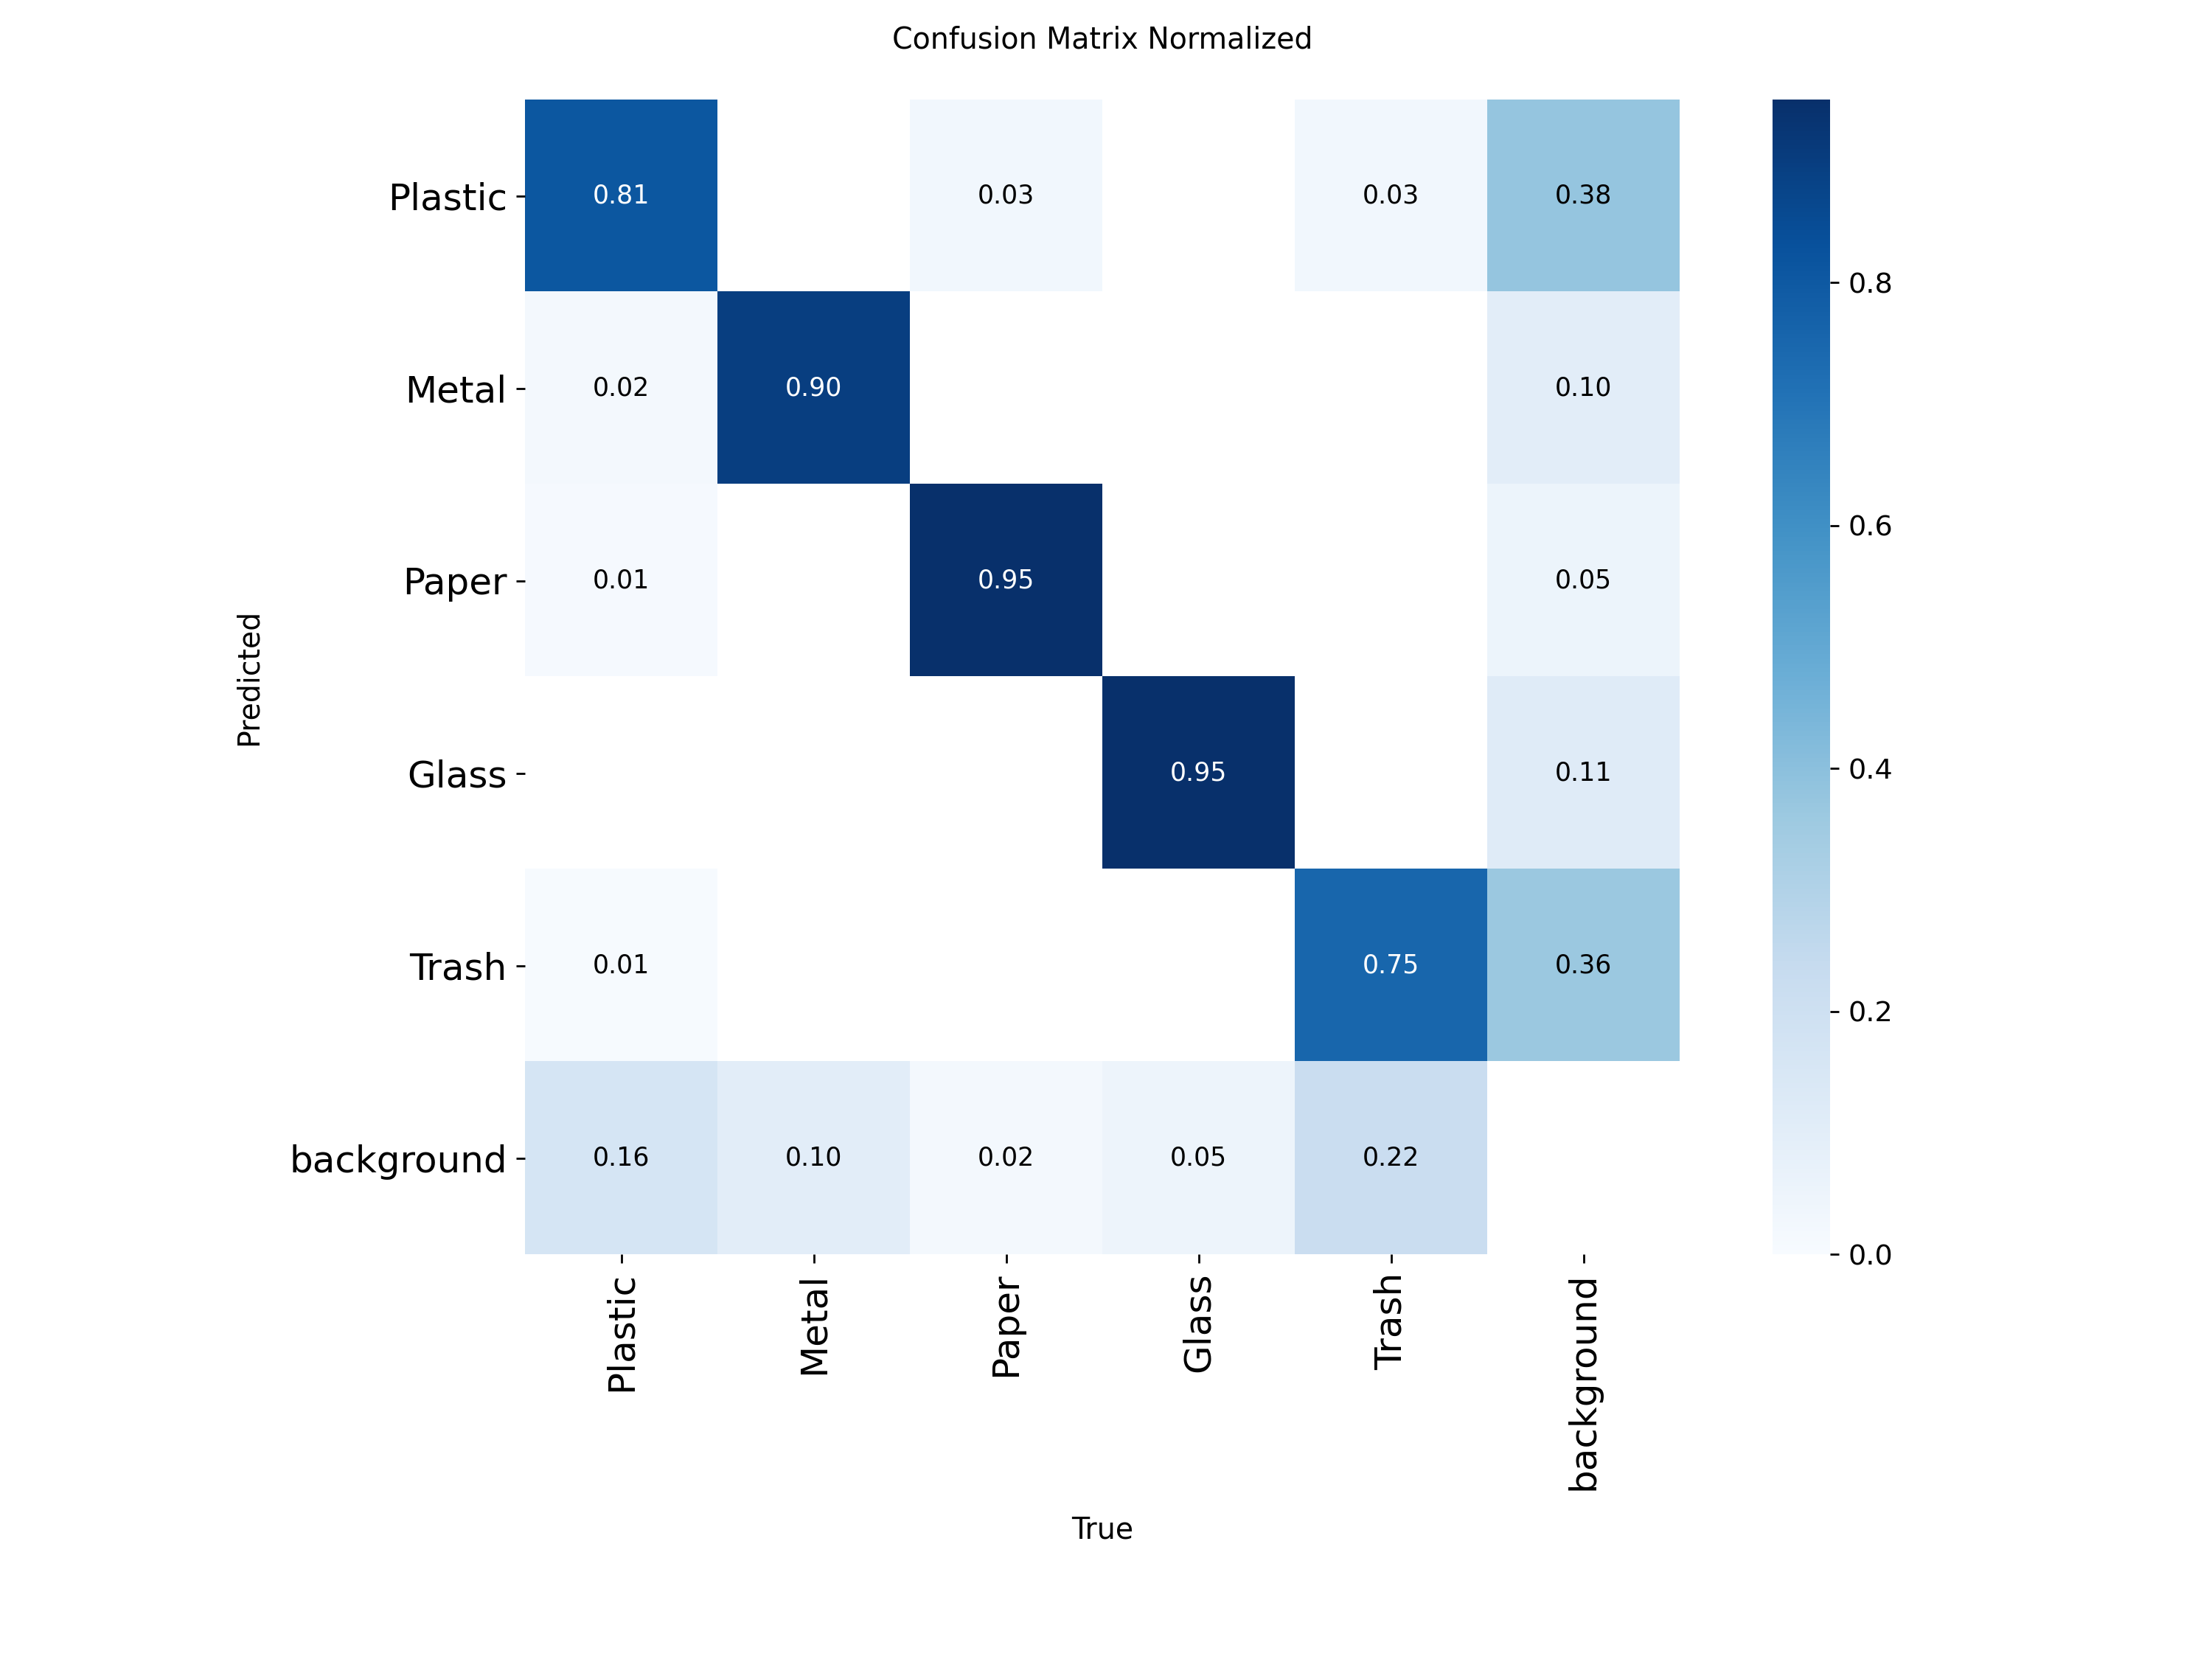


  Precision-Recall


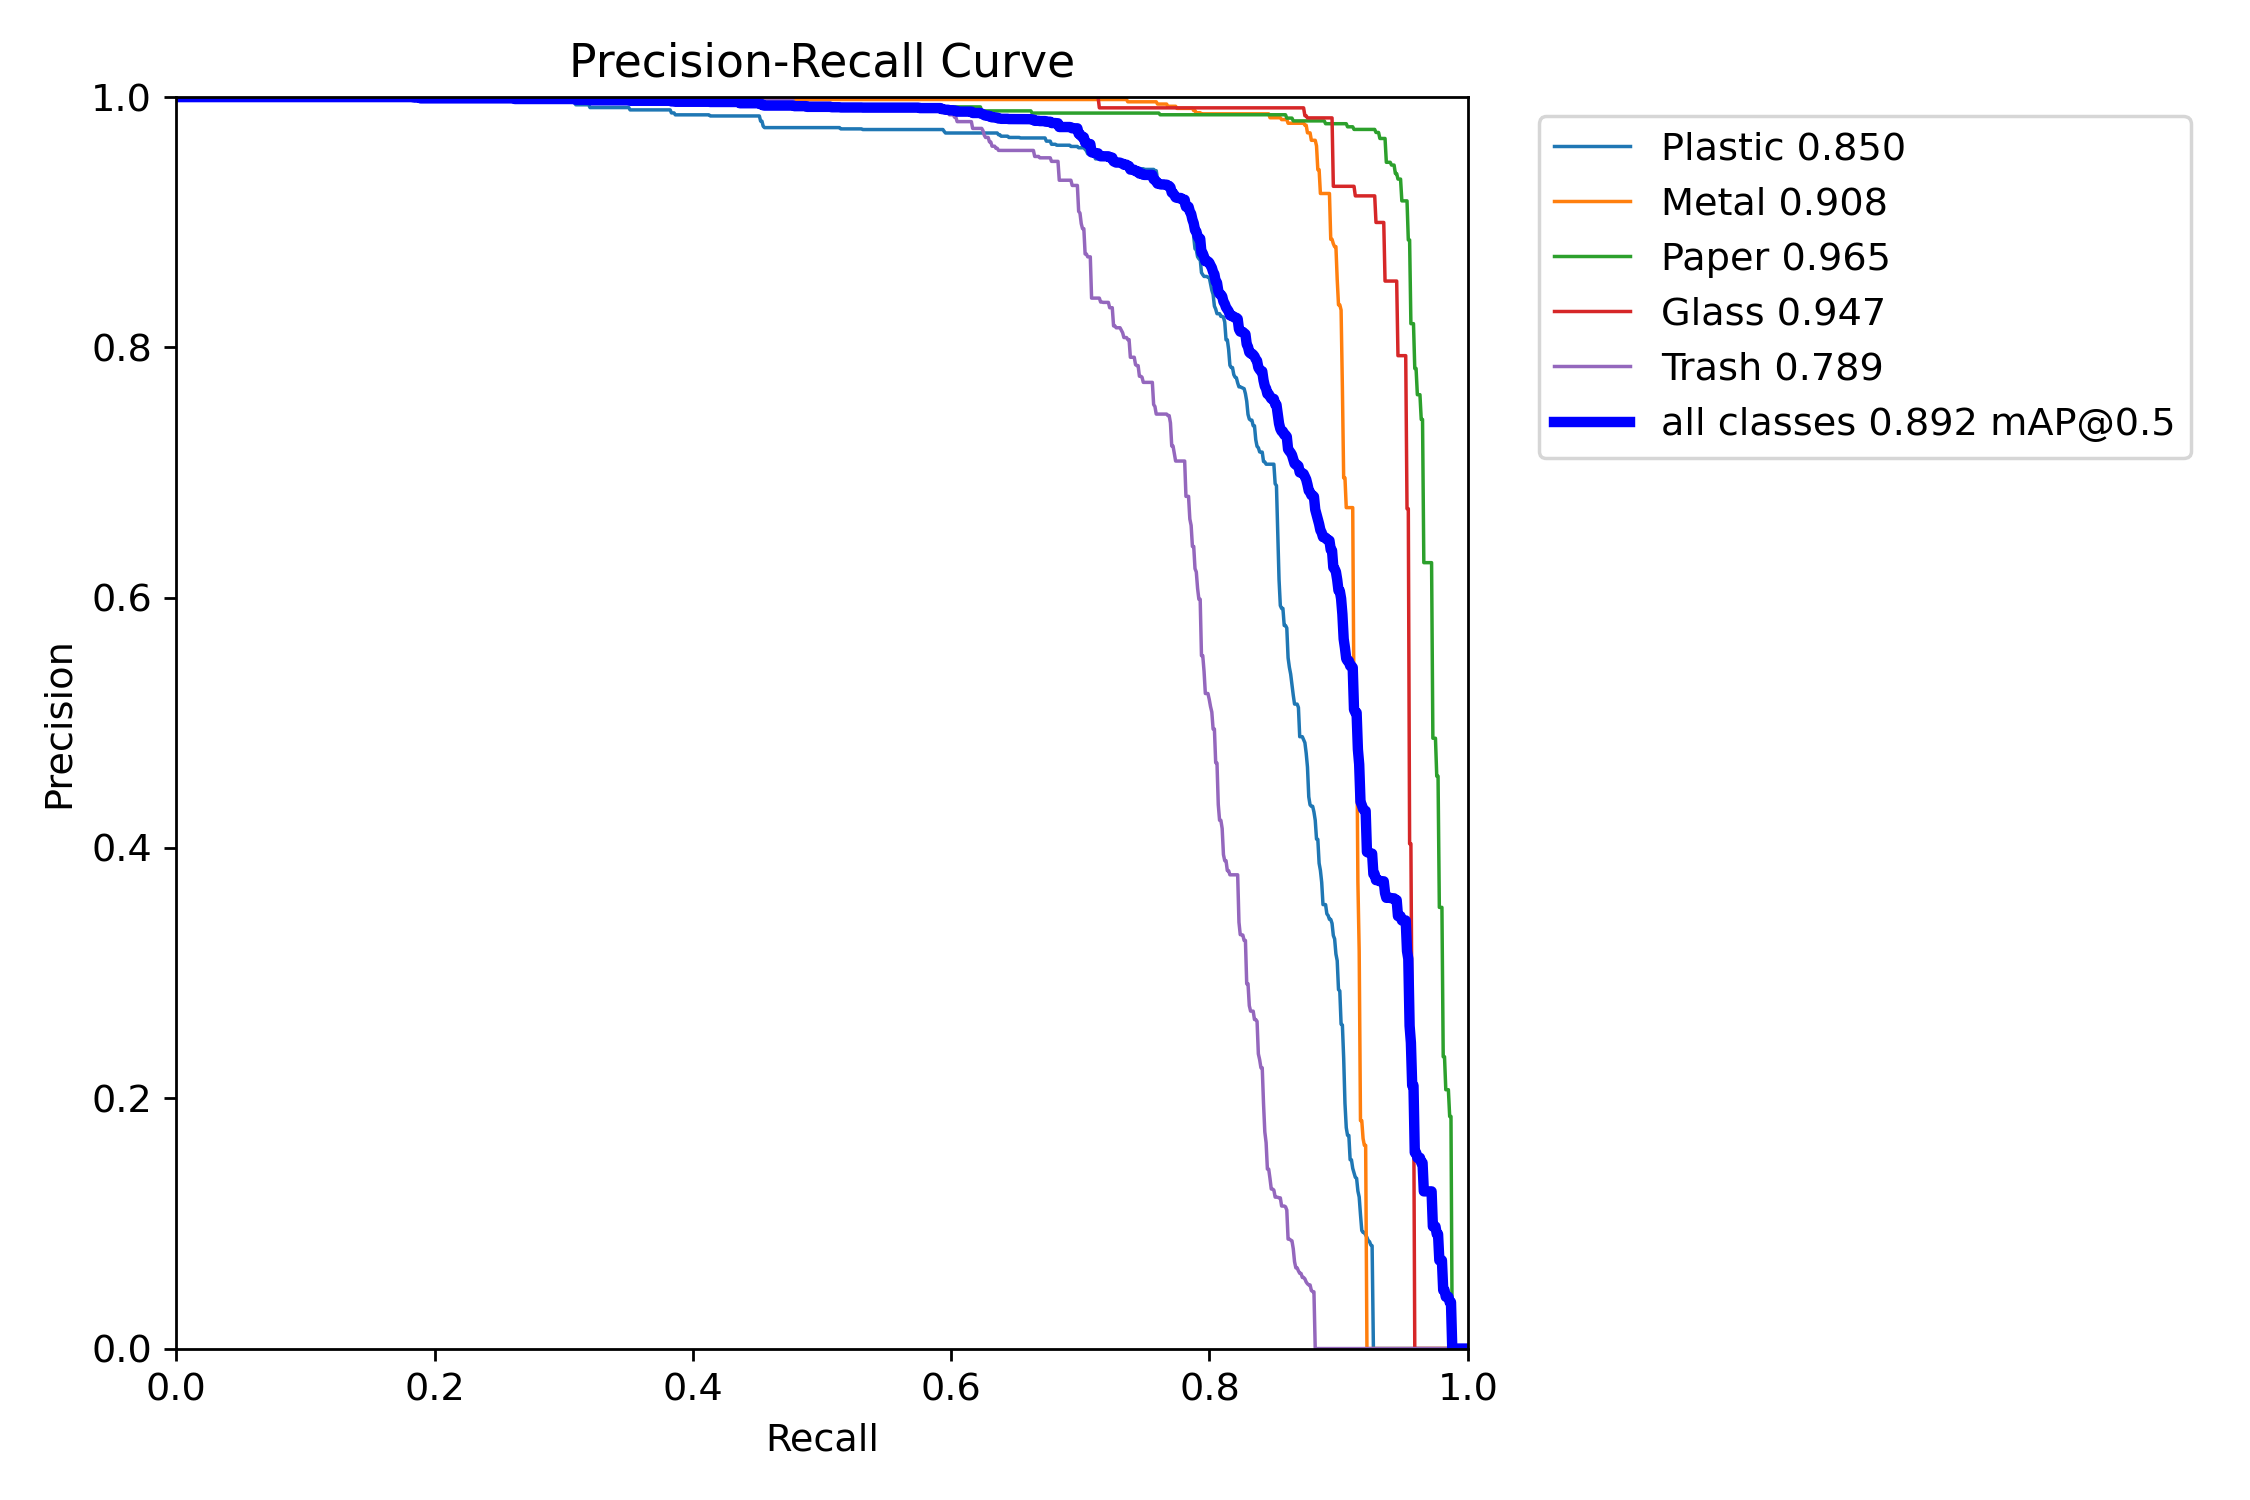


  Precision Curve


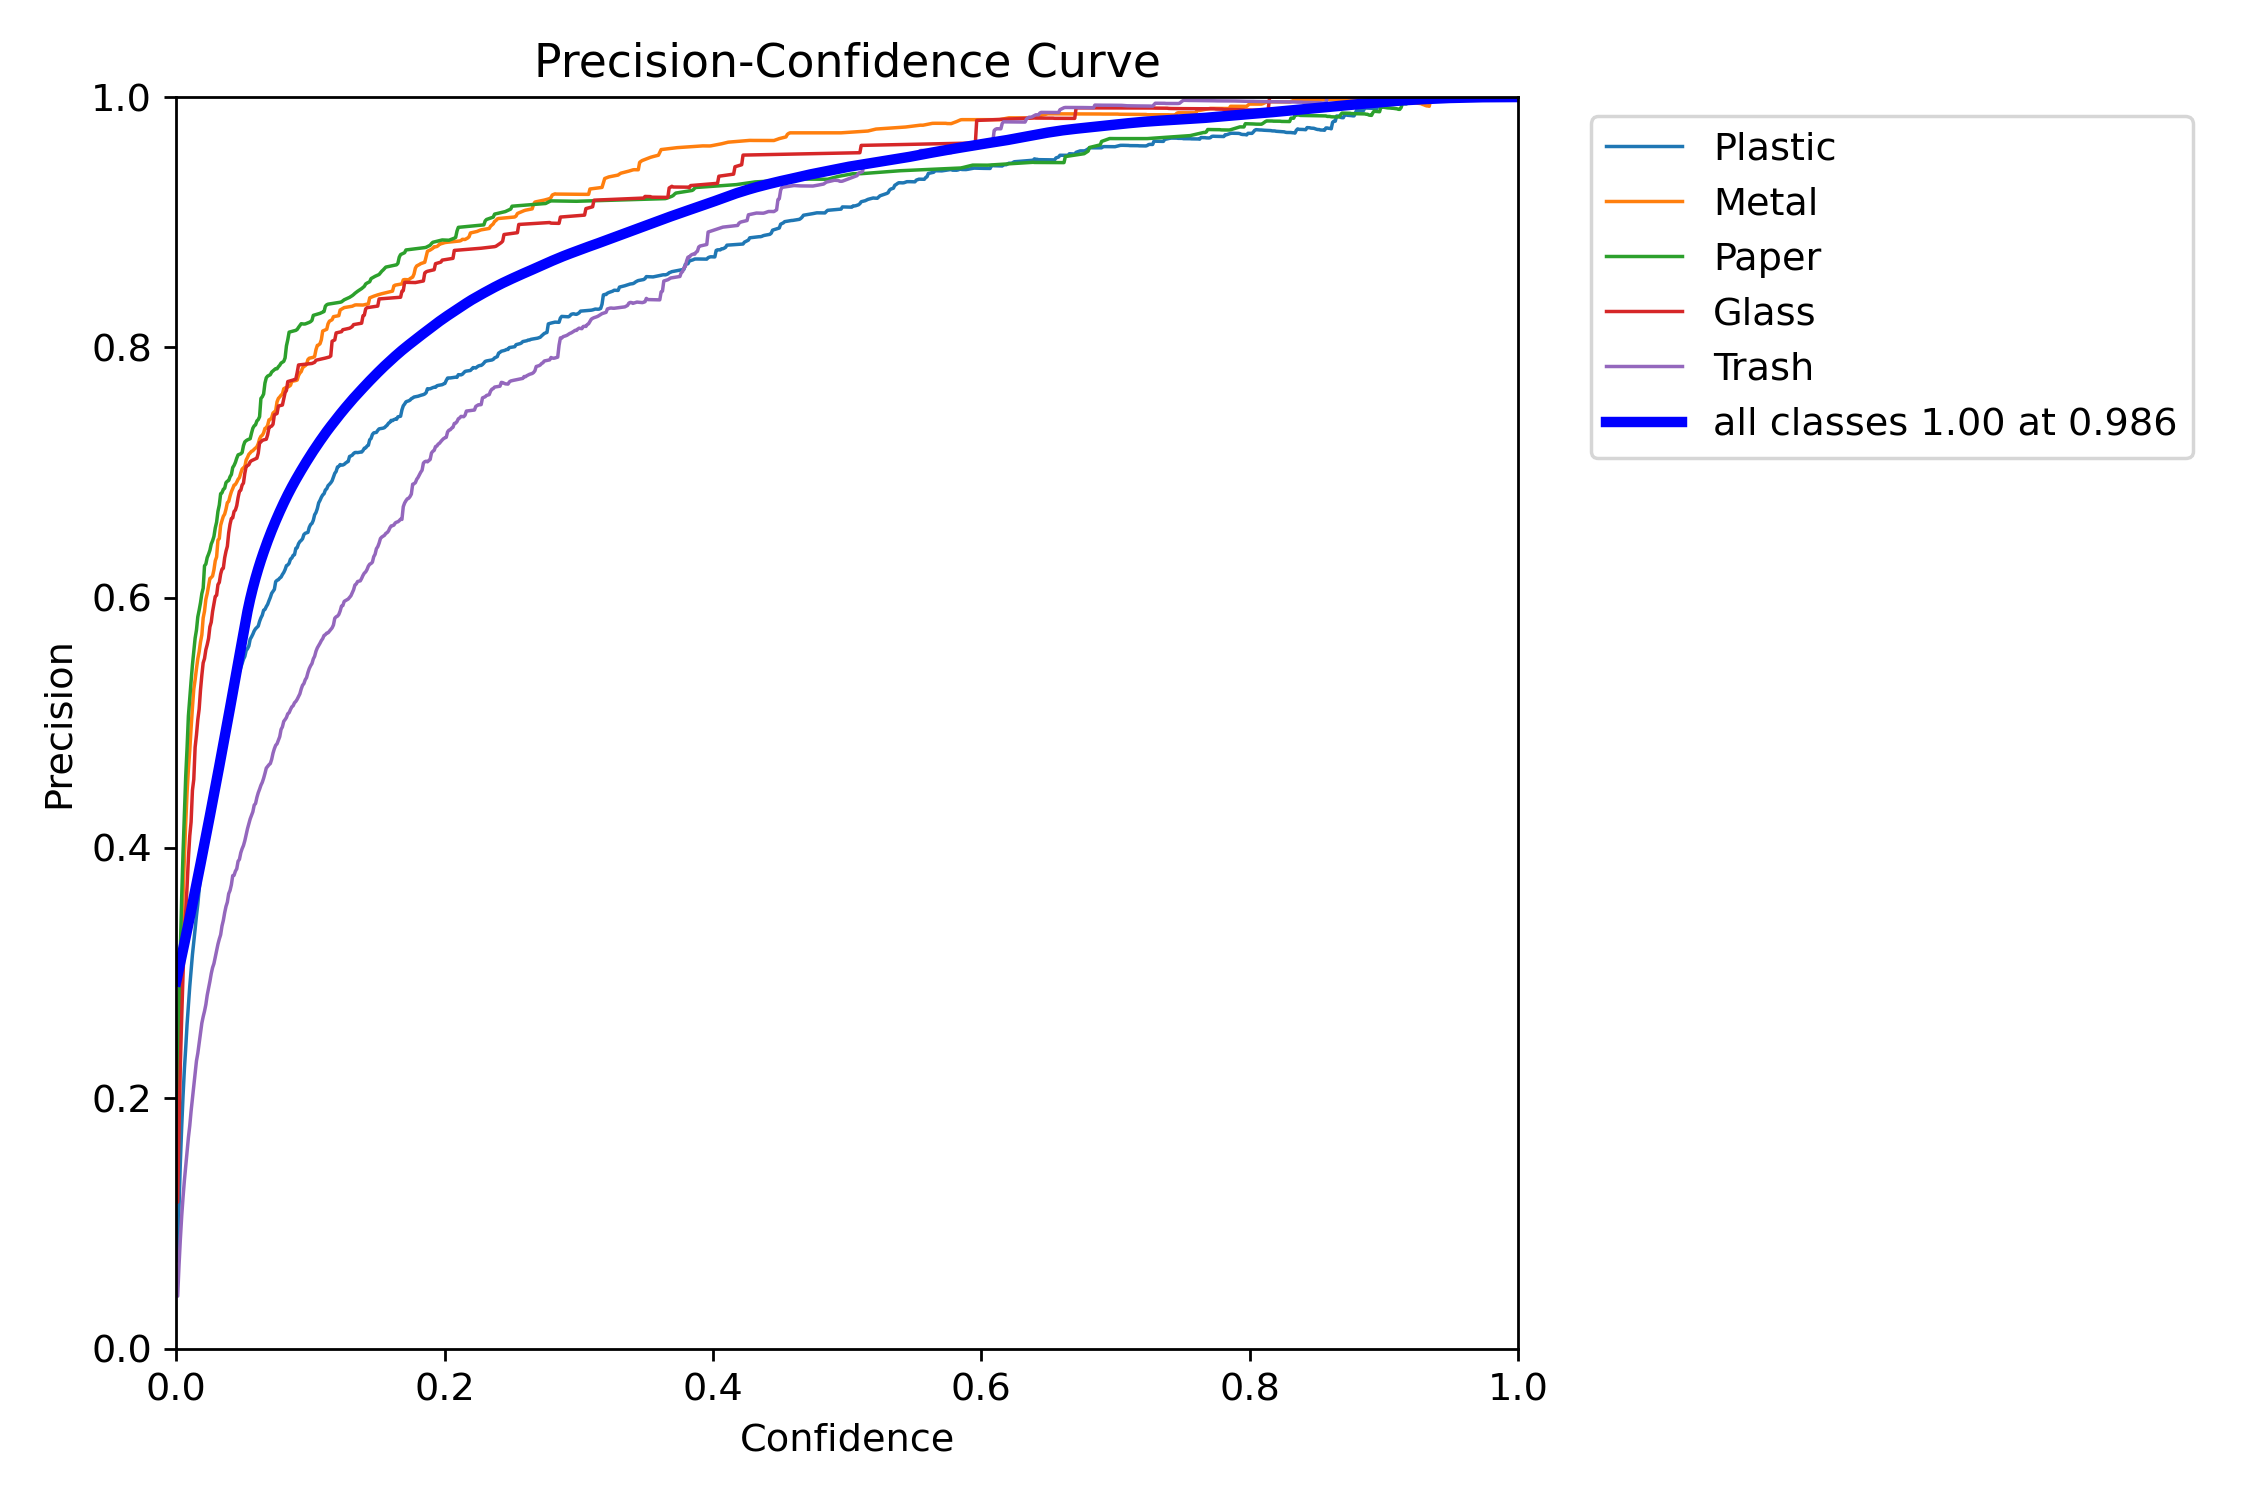


  Recall Curve


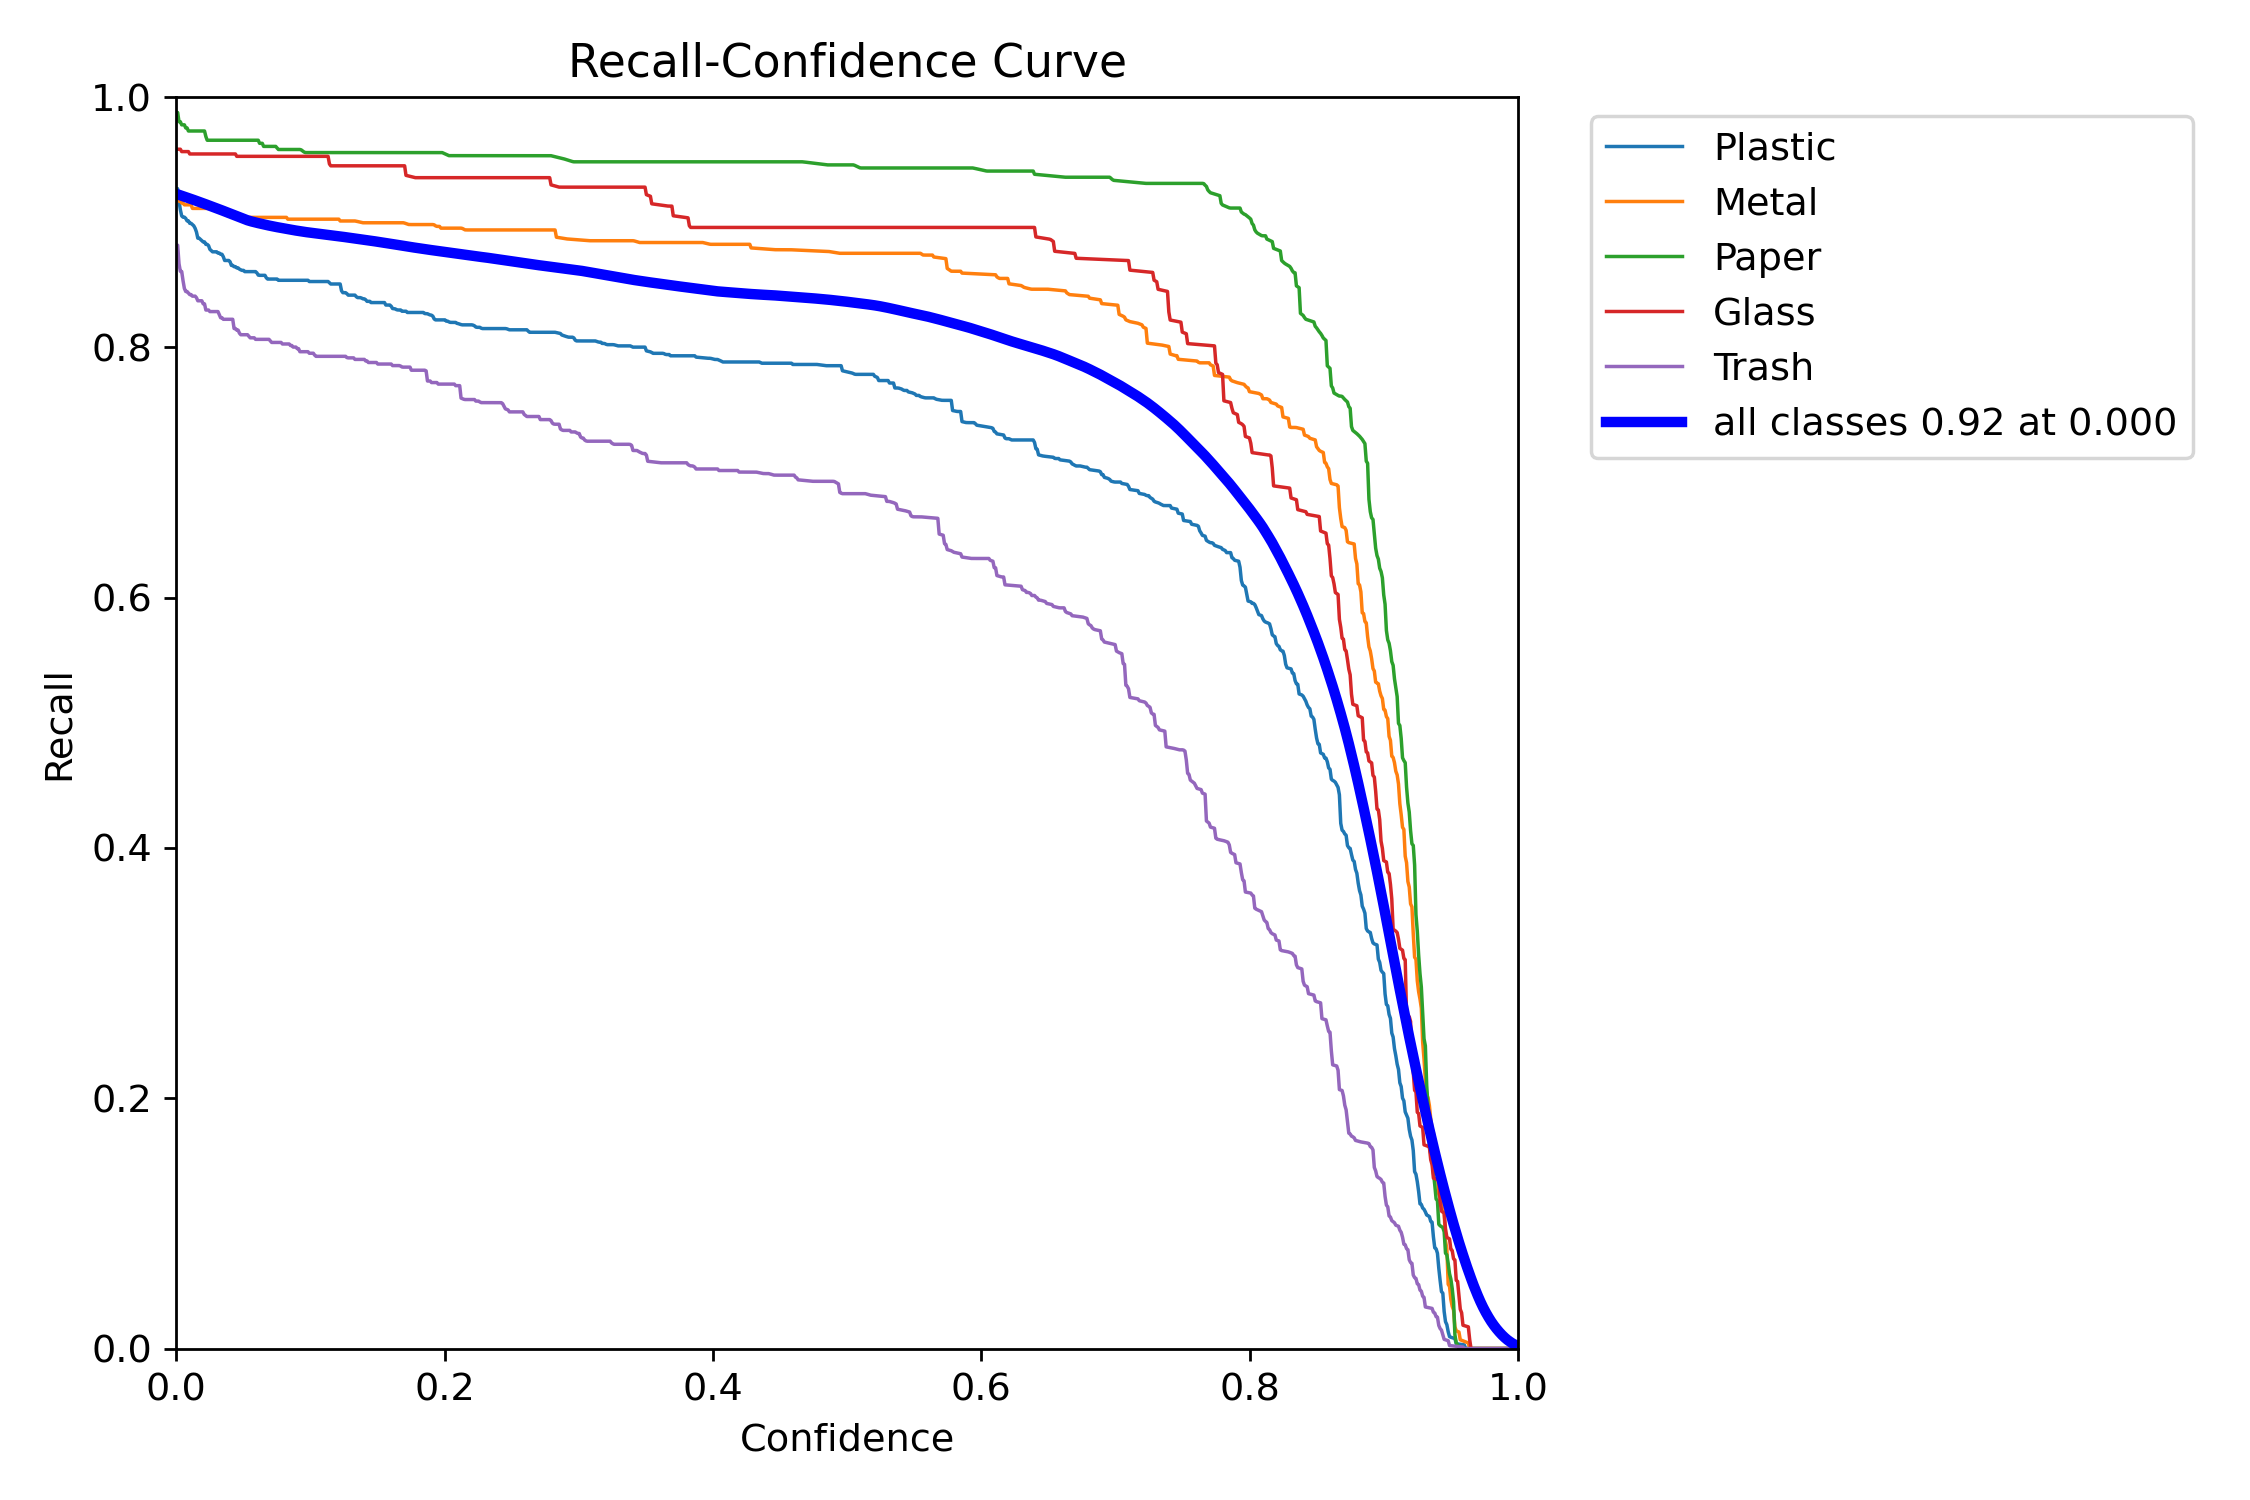


  Results


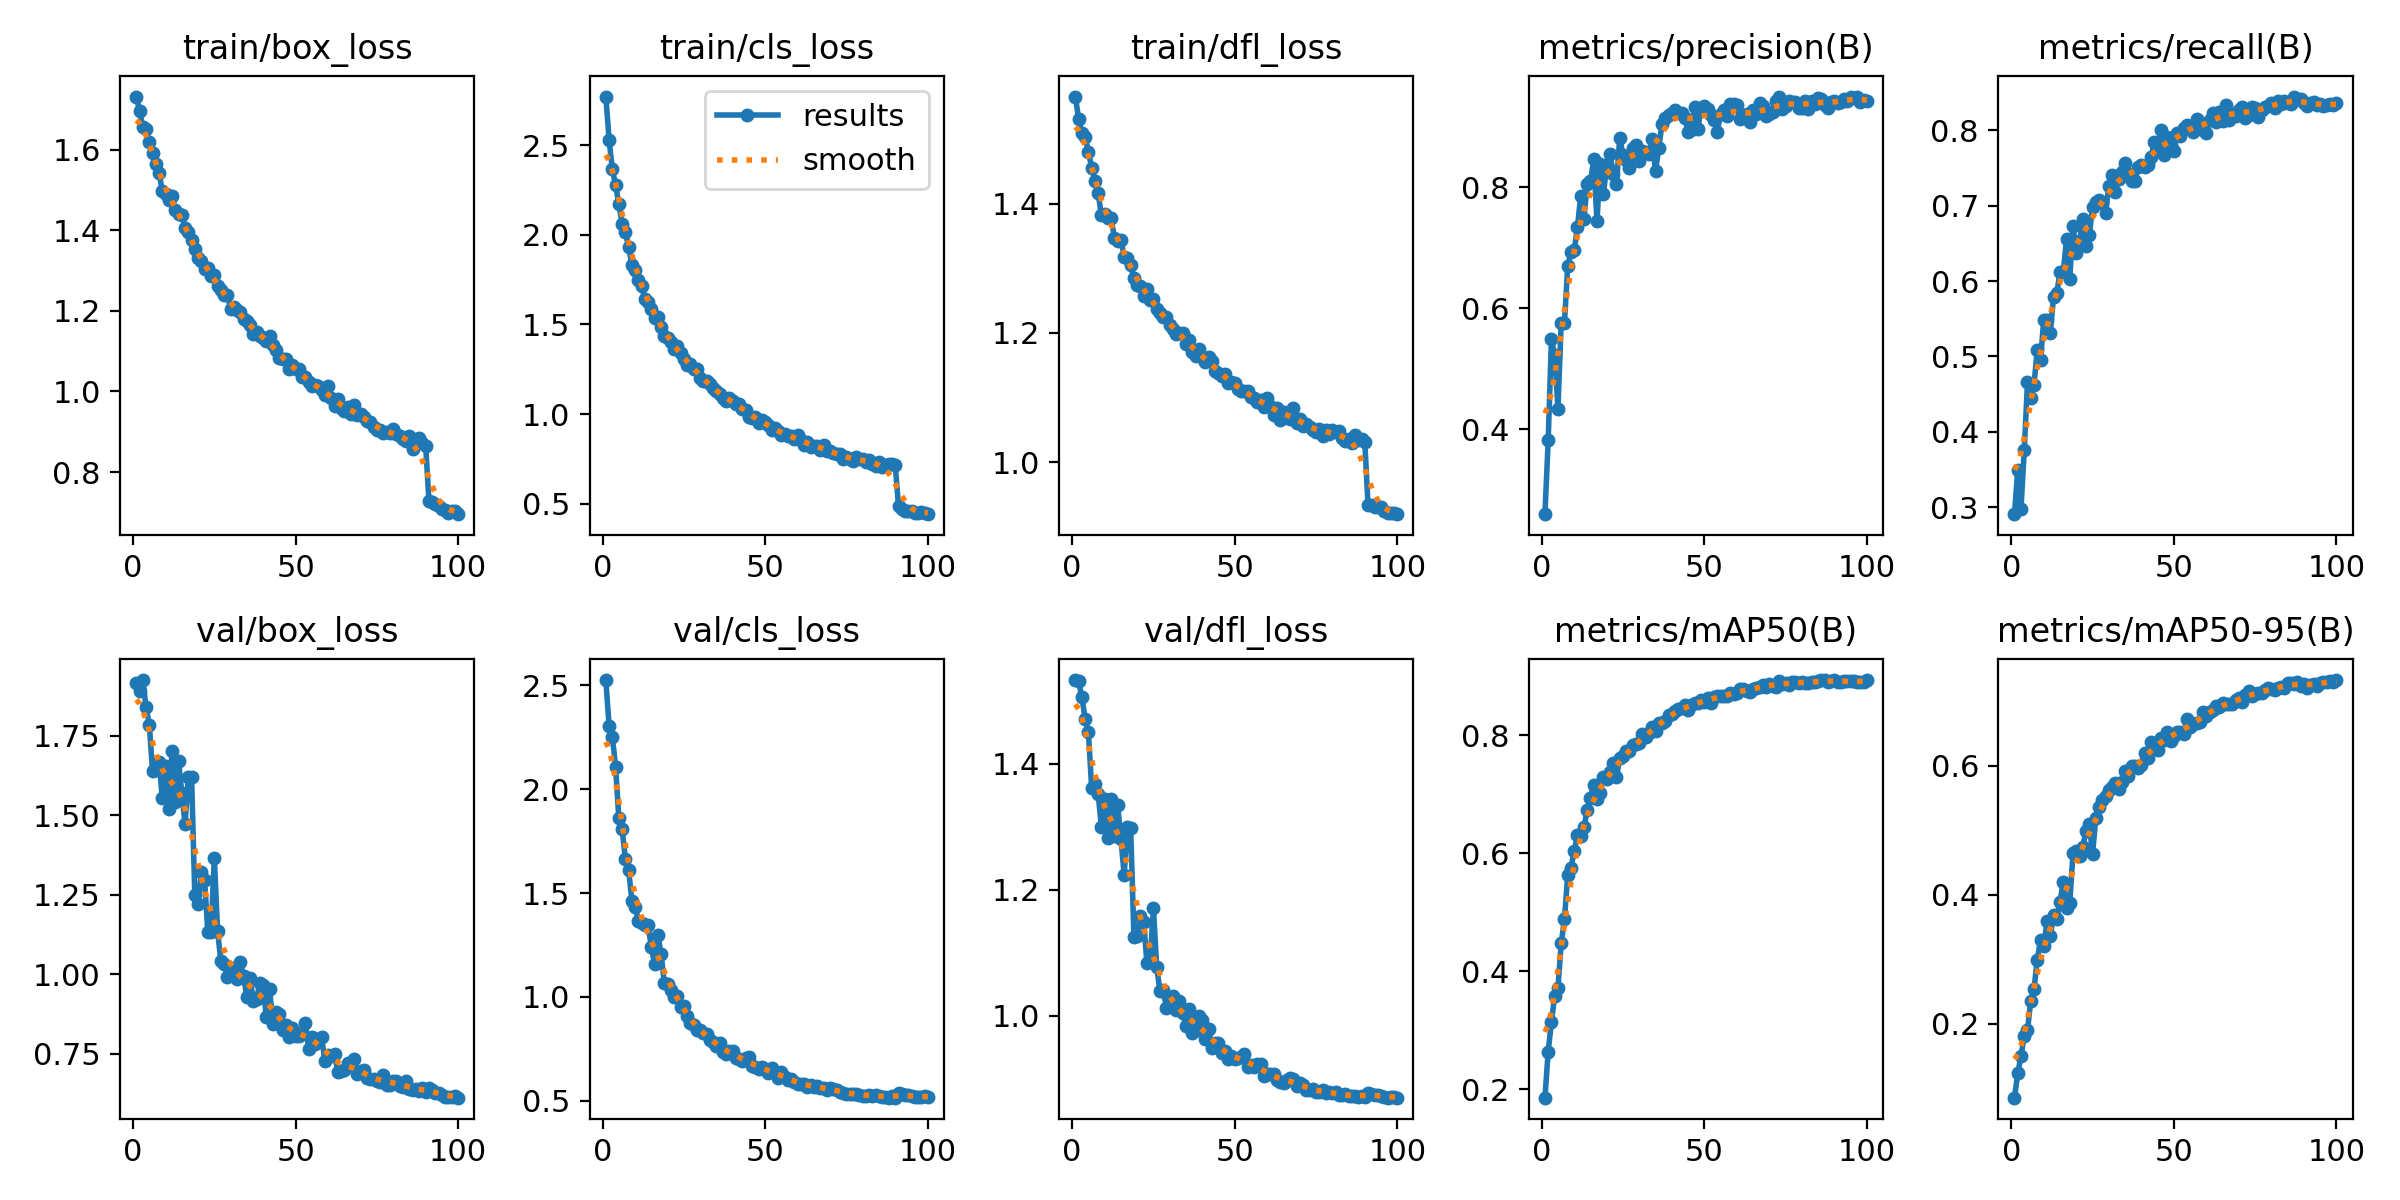

In [17]:
from IPython.display import Image, display
import os

run_path = "/content/runs/detect/yolov8_run/experiment_07_upgraded_brain"

plots = {
    "F1 Curve"          : "BoxF1_curve.png",
    "Confusion Matrix"  : "confusion_matrix.png",
    "Confusion Matrix (Normalized)": "confusion_matrix_normalized.png",
    "Precision-Recall"  : "BoxPR_curve.png",
    "Precision Curve"   : "BoxP_curve.png",
    "Recall Curve"      : "BoxR_curve.png",
    "Results"           : "results.png",
}

for title, filename in plots.items():
    path = os.path.join(run_path, filename)
    if os.path.exists(path):
        print(f"\n{'='*40}")
        print(f"  {title}")
        print(f"{'='*40}")
        display(Image(path))
    else:
        print(f"⚠️  {filename} not found")